In [1]:
import pandas as pd
import os

train_path = "data/UNSW_NB15/UNSW_NB15_training-set.csv"
test_path = "data/UNSW_NB15/UNSW_NB15_testing-set.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Original training shape:", train.shape)
print("Original testing shape:", test.shape)

# Remove ID because it is only an identifier
train = train.drop(columns=["id"], errors="ignore")
test = test.drop(columns=["id"], errors="ignore")

# Fill missing attack category values
train["attack_cat"] = train["attack_cat"].fillna("Normal")
test["attack_cat"] = test["attack_cat"].fillna("Normal")

# Separate features and binary target
X_train = train.drop(columns=["label", "attack_cat"])
y_train = train["label"]

X_test = test.drop(columns=["label", "attack_cat"])
y_test = test["label"]

# Find categorical columns
categorical_columns = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nCategorical columns:")
print(categorical_columns)

# One-hot encoding
X_train = pd.get_dummies(
    X_train,
    columns=categorical_columns,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_columns,
    dtype=int
)

# Make sure train and test contain the same columns
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

print("\nProcessed training shape:", X_train.shape)
print("Processed testing shape:", X_test.shape)

# Save processed datasets
os.makedirs("data/processed", exist_ok=True)

X_train.to_csv("data/processed/X_train.csv", index=False)
X_test.to_csv("data/processed/X_test.csv", index=False)

y_train.to_csv(
    "data/processed/y_train.csv",
    index=False
)

y_test.to_csv(
    "data/processed/y_test.csv",
    index=False
)

print("\nPreprocessing completed.")

Original training shape: (82332, 45)
Original testing shape: (175341, 45)

Categorical columns:
['proto', 'service', 'state']

Processed training shape: (82332, 190)
Processed testing shape: (175341, 190)

Preprocessing completed.


Dataset shape:
(82332, 45)

Columns:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

First five rows:
   id       dur proto service state  spkts  dpkts  sbytes  dbytes  \
0   1  0.000011   udp       -   INT      2      0     496       0   
1   2  0.000008   udp       -   INT      2      0    1762       0   
2   3  0.000005   udp       -   INT      2      0    1068       0   
3   4  0.000006   udp       -   INT      2      0     900       0   
4   5  0.000010   udp       -   INT      2      0    2126       0   

          rat

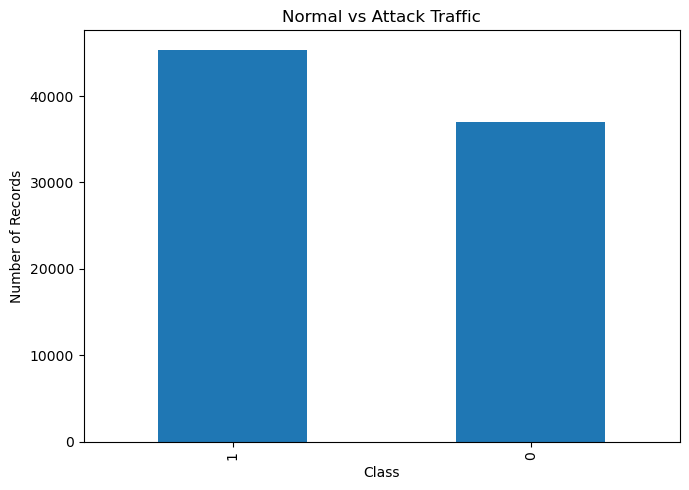

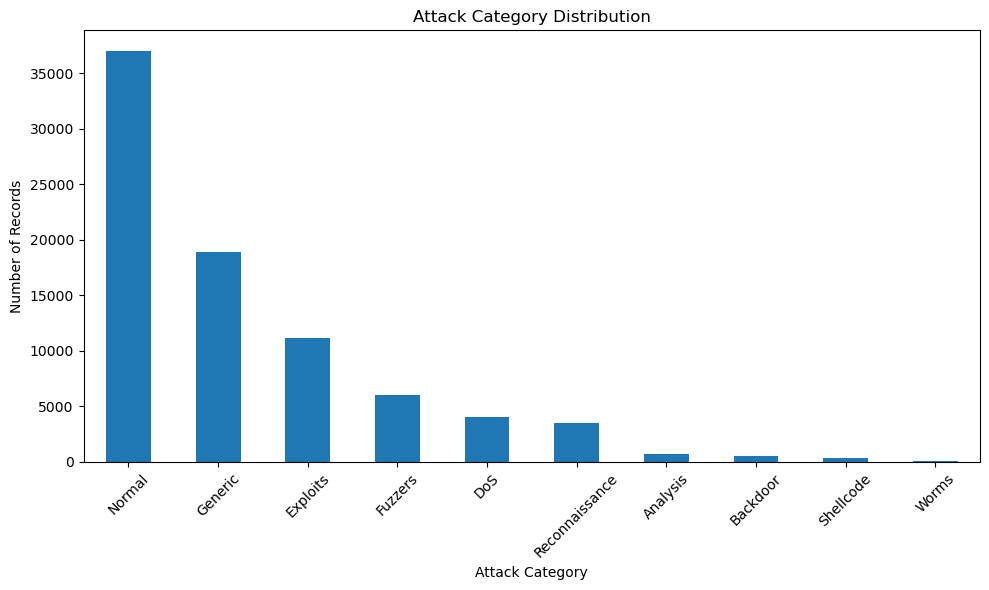

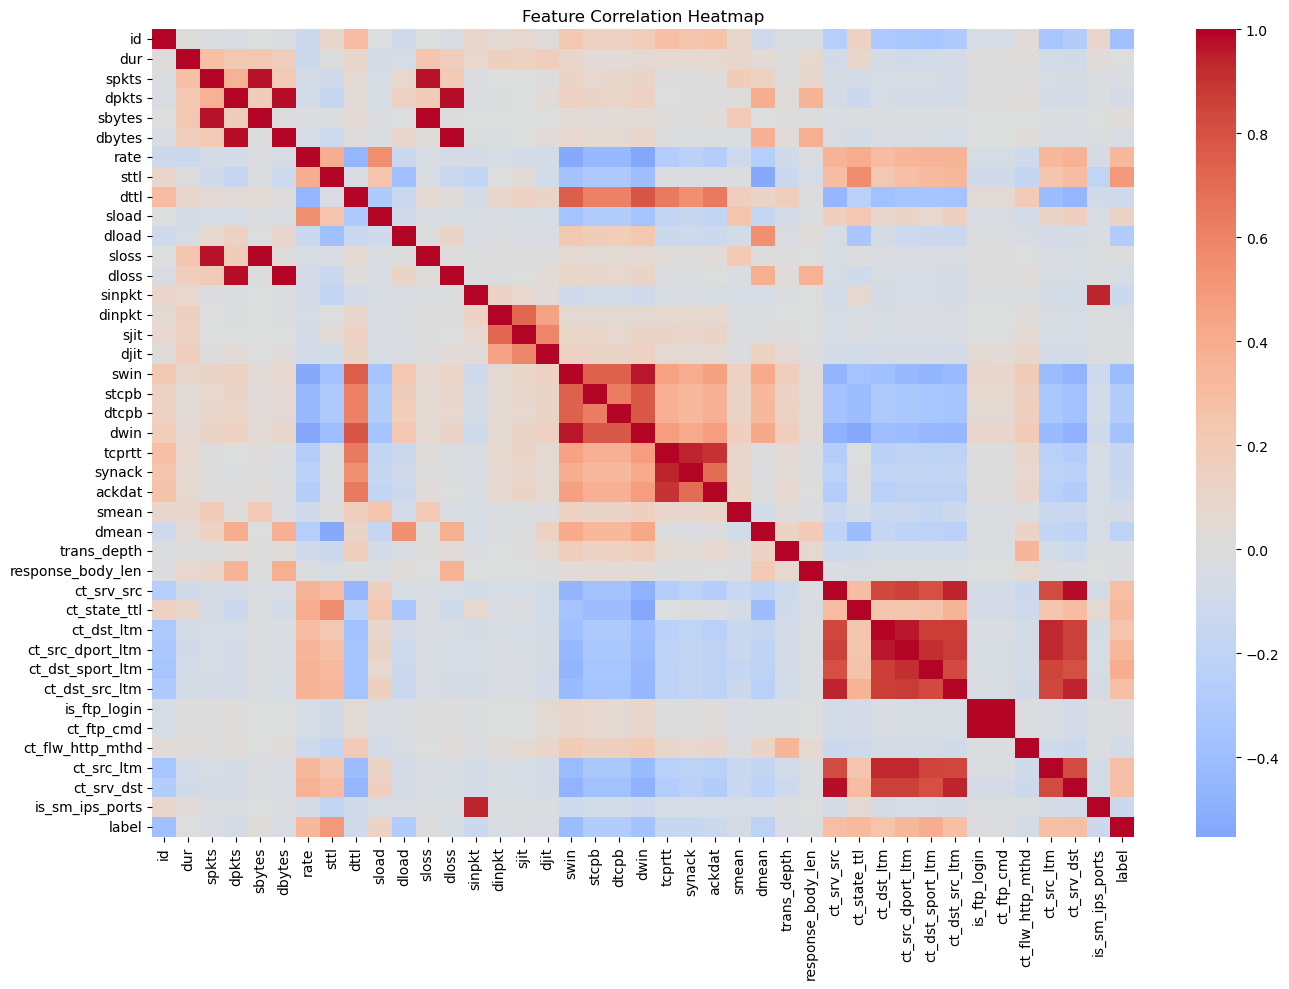

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

train_path = "data/UNSW_NB15/UNSW_NB15_training-set.csv"

df = pd.read_csv(train_path)

os.makedirs("graphs", exist_ok=True)

print("Dataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst five rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBinary class distribution:")
print(df["label"].value_counts())

print("\nAttack category distribution:")
print(df["attack_cat"].value_counts())

# -----------------------------
# Binary class distribution
# -----------------------------

df["label"].value_counts().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Normal vs Attack Traffic")
plt.xlabel("Class")
plt.ylabel("Number of Records")
plt.tight_layout()

plt.savefig(
    "graphs/class_distribution.png",
    dpi=300
)

plt.show()

# -----------------------------
# Attack category distribution
# -----------------------------

df["attack_cat"].value_counts().plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Attack Category Distribution")
plt.xlabel("Attack Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "graphs/attack_distribution.png",
    dpi=300
)

plt.show()

# -----------------------------
# Numeric correlation
# -----------------------------

numeric_df = df.select_dtypes(
    include=["number"]
)

correlation = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()

plt.savefig(
    "graphs/correlation_heatmap.png",
    dpi=300
)

plt.show()

In [3]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import os
import time

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# -----------------------------
# Load processed data
# -----------------------------

X_train = pd.read_csv(
    "data/processed/X_train.csv"
)

X_test = pd.read_csv(
    "data/processed/X_test.csv"
)

y_train = pd.read_csv(
    "data/processed/y_train.csv"
).iloc[:, 0]

y_test = pd.read_csv(
    "data/processed/y_test.csv"
).iloc[:, 0]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

os.makedirs("models", exist_ok=True)

# -----------------------------
# Decision Tree
# -----------------------------

print("\nTraining Decision Tree...")

start = time.time()

dt = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=10,
    random_state=42
)

dt.fit(X_train, y_train)

dt_train_time = time.time() - start

print(
    "Decision Tree training time:",
    round(dt_train_time, 3),
    "seconds"
)

# -----------------------------
# Random Forest
# -----------------------------

print("\nTraining Random Forest...")

start = time.time()

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_train_time = time.time() - start

print(
    "Random Forest training time:",
    round(rf_train_time, 3),
    "seconds"
)

# -----------------------------
# XGBoost
# -----------------------------

print("\nTraining XGBoost...")

start = time.time()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_train_time = time.time() - start

print(
    "XGBoost training time:",
    round(xgb_train_time, 3),
    "seconds"
)

# -----------------------------
# Save models
# -----------------------------

import joblib

joblib.dump(
    dt,
    "models/decision_tree.pkl"
)

joblib.dump(
    rf,
    "models/random_forest.pkl"
)

joblib.dump(
    xgb,
    "models/xgboost.pkl"
)

print("\nAll models saved successfully.")

Training data: (82332, 190)
Testing data: (175341, 190)

Training Decision Tree...
Decision Tree training time: 2.3 seconds

Training Random Forest...
Random Forest training time: 4.89 seconds

Training XGBoost...
XGBoost training time: 7.459 seconds

All models saved successfully.



Decision Tree
Accuracy : 0.892683399775295
Precision: 0.9155495774385727
Recall   : 0.892683399775295
F1 Score : 0.895637068305103
Testing time: 0.3013424873352051

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.98      0.85     56000
           1       0.99      0.85      0.92    119341

    accuracy                           0.89    175341
   macro avg       0.87      0.92      0.88    175341
weighted avg       0.92      0.89      0.90    175341



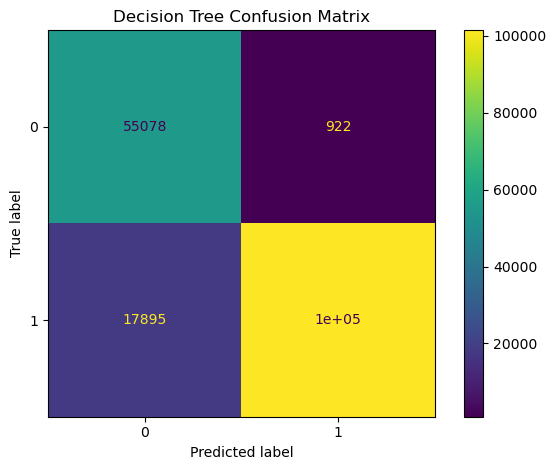


Random Forest
Accuracy : 0.9043349815502364
Precision: 0.9212364039338536
Recall   : 0.9043349815502364
F1 Score : 0.9066928943890569
Testing time: 0.8604738712310791

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.98      0.87     56000
           1       0.99      0.87      0.93    119341

    accuracy                           0.90    175341
   macro avg       0.88      0.92      0.90    175341
weighted avg       0.92      0.90      0.91    175341



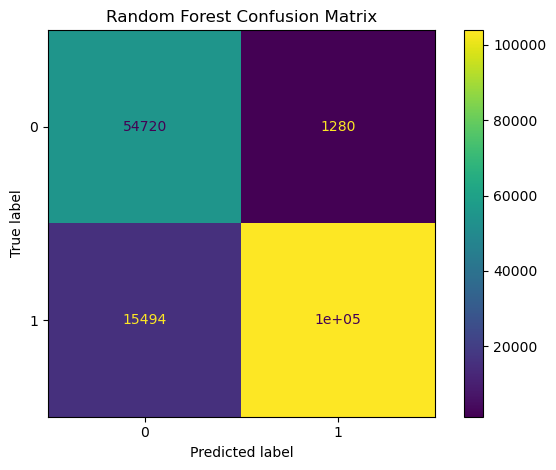


XGBoost
Accuracy : 0.899378924495697
Precision: 0.9182548195613564
Recall   : 0.899378924495697
F1 Score : 0.9019635241099502
Testing time: 0.4745676517486572

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.98      0.86     56000
           1       0.99      0.86      0.92    119341

    accuracy                           0.90    175341
   macro avg       0.88      0.92      0.89    175341
weighted avg       0.92      0.90      0.90    175341



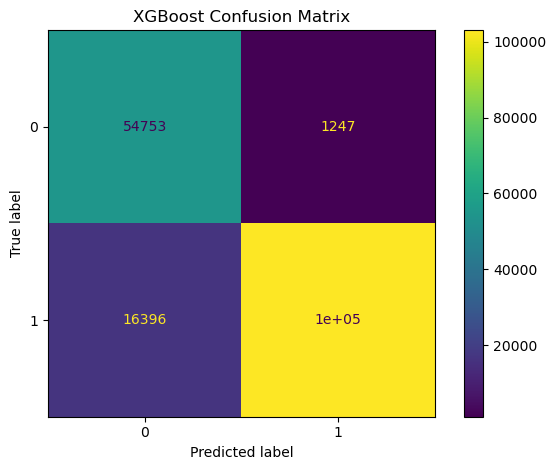



FINAL MODEL COMPARISON
           Model  Accuracy  Precision    Recall  F1 Score  Testing Time
0  Decision Tree  0.892683   0.915550  0.892683  0.895637      0.301342
1  Random Forest  0.904335   0.921236  0.904335  0.906693      0.860474
2        XGBoost  0.899379   0.918255  0.899379  0.901964      0.474568


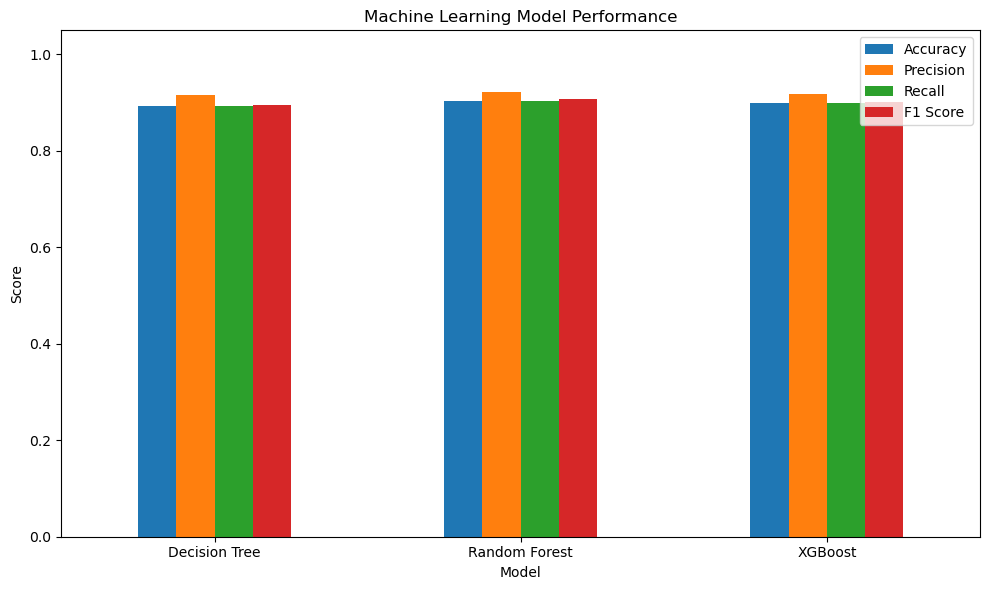

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
import time

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# -----------------------------
# Load data
# -----------------------------

X_test = pd.read_csv(
    "data/processed/X_test.csv"
)

y_test = pd.read_csv(
    "data/processed/y_test.csv"
).iloc[:, 0]

# -----------------------------
# Load models
# -----------------------------

models = {
    "Decision Tree": joblib.load(
        "models/decision_tree.pkl"
    ),

    "Random Forest": joblib.load(
        "models/random_forest.pkl"
    ),

    "XGBoost": joblib.load(
        "models/xgboost.pkl"
    )
}

os.makedirs("graphs", exist_ok=True)

results = []

# -----------------------------
# Evaluate each model
# -----------------------------

for name, model in models.items():

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    start = time.time()

    predictions = model.predict(X_test)

    test_time = time.time() - start

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("Testing time:", test_time)

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Testing Time": test_time
    })

    # -----------------------------
    # Confusion matrix
    # -----------------------------

    cm = confusion_matrix(
        y_test,
        predictions
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    display.plot()

    plt.title(
        name + " Confusion Matrix"
    )

    plt.tight_layout()

    filename = name.lower().replace(
        " ",
        "_"
    )

    plt.savefig(
        "graphs/" + filename + "_confusion_matrix.png",
        dpi=300
    )

    plt.show()

# -----------------------------
# Results table
# -----------------------------

results_df = pd.DataFrame(results)

print("\n")
print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

print(results_df)

results_df.to_csv(
    "model_results.csv",
    index=False
)

# -----------------------------
# Performance graph
# -----------------------------

results_df.plot(
    x="Model",
    y=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Machine Learning Model Performance"
)

plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "graphs/model_comparison.png",
    dpi=300
)

plt.show()


Top 20 features:
dinpkt              0.017897
dpkts               0.023169
ct_srv_src          0.025923
tcprtt              0.025936
dur                 0.027695
sinpkt              0.028087
dttl                0.028183
dload               0.028655
dmean               0.029969
synack              0.031725
dbytes              0.036344
rate                0.041508
ct_dst_sport_ltm    0.041918
ct_state_ttl        0.042448
ct_srv_dst          0.042911
smean               0.044472
sbytes              0.053775
sload               0.058677
sttl                0.061689
ct_dst_src_ltm      0.074100
dtype: float64


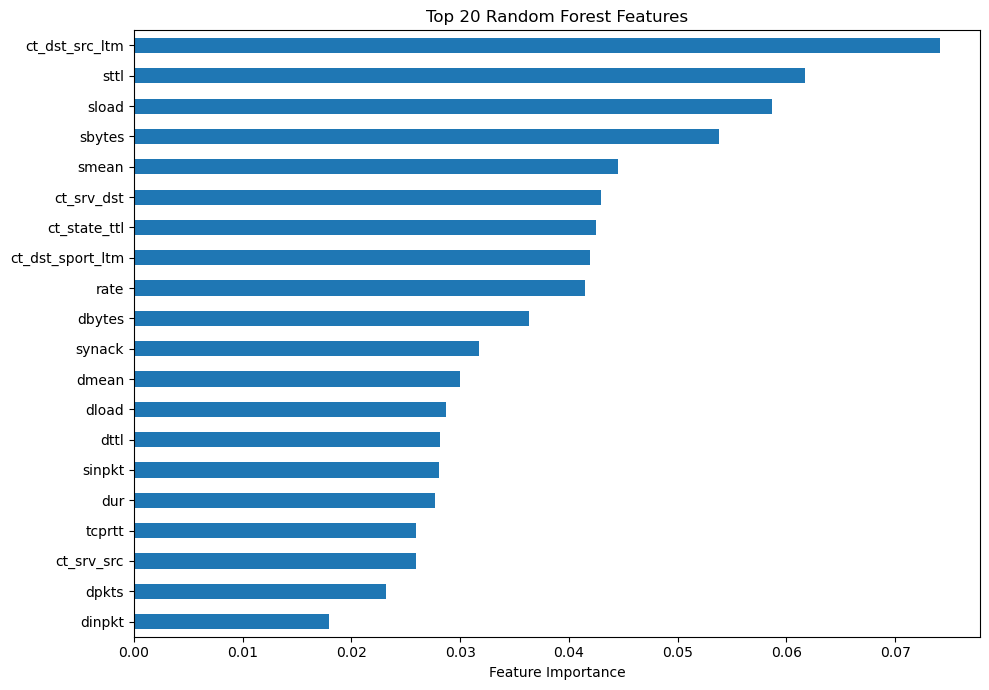

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

# Load model
rf = joblib.load(
    "models/random_forest.pkl"
)

# Load training data
X_train = pd.read_csv(
    "data/processed/X_train.csv"
)

# Get feature importance
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
)

# Select top 20
top_features = (
    importance
    .sort_values(ascending=False)
    .head(20)
    .sort_values()
)

print("\nTop 20 features:")
print(top_features)

# Plot
os.makedirs("graphs", exist_ok=True)

top_features.plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title(
    "Top 20 Random Forest Features"
)

plt.xlabel(
    "Feature Importance"
)

plt.tight_layout()

plt.savefig(
    "graphs/feature_importance.png",
    dpi=300
)

plt.show()

In [9]:
import pandas as pd
import joblib
import random

# Load the trained Random Forest
rf = joblib.load("models/random_forest.pkl")

# Load processed test data
X_test = pd.read_csv("data/processed/X_test.csv")
y_test = pd.read_csv("data/processed/y_test.csv").iloc[:, 0]

# Select 10 random records
random.seed(42)
sample_numbers = random.sample(range(len(X_test)), 10)

results = []

for number in sample_numbers:

    sample = X_test.iloc[[number]]

    prediction = rf.predict(sample)[0]
    probability = rf.predict_proba(sample)[0]
    actual = y_test.iloc[number]

    if prediction == 0:
        predicted_label = "Normal"
        confidence = probability[0] * 100
    else:
        predicted_label = "Attack"
        confidence = probability[1] * 100

    if actual == 0:
        actual_label = "Normal"
    else:
        actual_label = "Attack"

    result = "Correct" if prediction == actual else "Wrong"

    results.append({
        "Record": number,
        "Prediction": predicted_label,
        "Confidence (%)": round(confidence, 2),
        "Actual": actual_label,
        "Result": result
    })

results_df = pd.DataFrame(results)

results_df

,Record,Prediction,Confidence (%),Actual,Result
0,167621,Attack,93.0,Attack,Correct
1,29184,Normal,100.0,Normal,Correct
2,6556,Normal,100.0,Normal,Correct
3,72097,Attack,92.0,Attack,Correct
4,64196,Normal,90.0,Attack,Wrong
5,58513,Attack,100.0,Attack,Correct
6,36579,Normal,100.0,Normal,Correct
7,26868,Normal,100.0,Normal,Correct
8,142964,Attack,100.0,Attack,Correct
9,22790,Normal,100.0,Normal,Correct
